<a href="https://colab.research.google.com/github/anjali-0404/AIML-practice/blob/main/Student%20Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# 📘 Student Dashboard Project
# Full End-to-End Implementation
# ================================

# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve
)
import joblib
import os

# ================================
# 2. Generate Synthetic Student Dataset
# ================================
def generate_student_data(n=1500, random_state=42):
    rng = np.random.RandomState(random_state)
    gender = rng.choice(['F', 'M'], size=n)
    school = rng.choice(['GP', 'MS'], size=n, p=[0.7,0.3])
    address = rng.choice(['U','R'], size=n, p=[0.8,0.2])
    family_size = rng.choice(['LE3','GT3'], size=n)
    parents_status = rng.choice(['together','apart'], size=n, p=[0.85,0.15])

    age = rng.randint(15, 22, size=n)
    study_time = rng.choice([1,2,3,4], size=n, p=[0.2,0.5,0.2,0.1])
    failures = rng.choice([0,1,2,3], size=n, p=[0.75,0.15,0.07,0.03])
    absences = rng.poisson(5, size=n)

    G1 = np.clip(rng.normal(12, 3, n) + study_time, 0, 20)
    G2 = np.clip(G1 + rng.normal(1, 2, n), 0, 20)

    final_grade = (
        0.4*G2 + 0.2*study_time*3 - 1.2*failures - 0.05*absences
        + rng.normal(0,2,n) + 5
    )
    final_grade = np.clip(final_grade, 0, 20)
    pass_fail = (final_grade >= 10).astype(int)

    df = pd.DataFrame({
        "gender": gender, "school": school, "address": address,
        "family_size": family_size, "parents_status": parents_status,
        "age": age, "study_time": study_time, "failures": failures,
        "absences": absences, "G1": np.round(G1,1), "G2": np.round(G2,1),
        "final_grade": np.round(final_grade,1), "pass_fail": pass_fail
    })

    # introduce missing values
    for col in ['G1','G2','study_time']:
        mask = rng.rand(n) < 0.02
        df.loc[mask, col] = np.nan
    return df

df = generate_student_data()
df.to_csv("students.csv", index=False)
df.head()


,gender,school,address,family_size,parents_status,age,study_time,failures,absences,G1,G2,final_grade,pass_fail
0,F,GP,U,GT3,together,15,4.0,0,4,20.0,20.0,14.0,1
1,M,MS,R,GT3,together,15,2.0,0,5,15.2,15.4,10.8,1
2,F,GP,U,LE3,together,17,2.0,3,5,18.4,16.7,10.5,1
3,F,GP,R,GT3,together,19,2.0,1,9,10.7,9.3,5.7,0
4,F,GP,R,LE3,together,19,3.0,0,5,19.6,19.8,14.7,1


In [ ]:
# ================================
# 3. Data Cleaning & Preprocessing
# ================================

print("Missing values:\n", df.isnull().sum())

cat_features = ['gender','school','address','family_size','parents_status']
num_features = ['age','study_time','failures','absences','G1','G2']

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])


Missing values:
 gender             0
school             0
address            0
family_size        0
parents_status     0
age                0
study_time        27
failures           0
absences           0
G1                34
G2                21
final_grade        0
pass_fail          0
dtype: int64


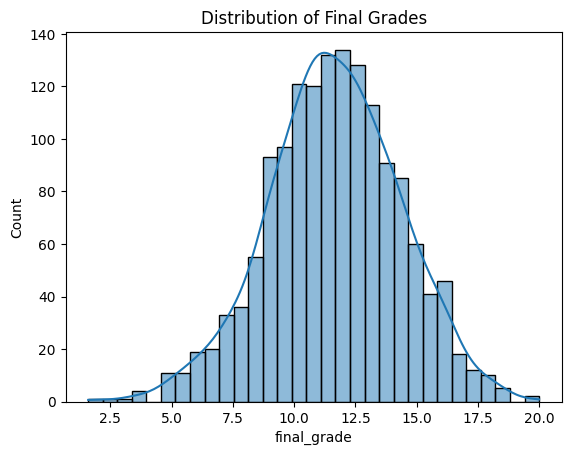

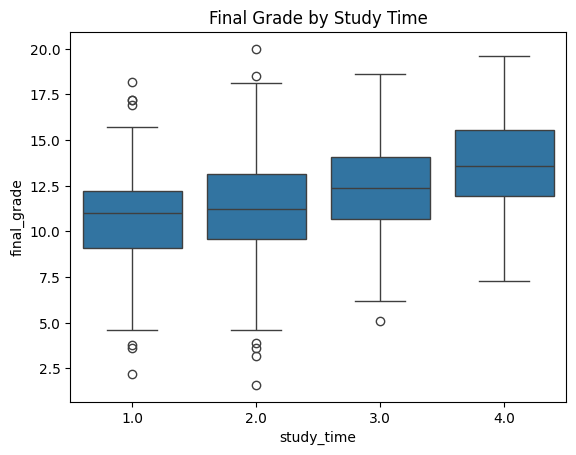

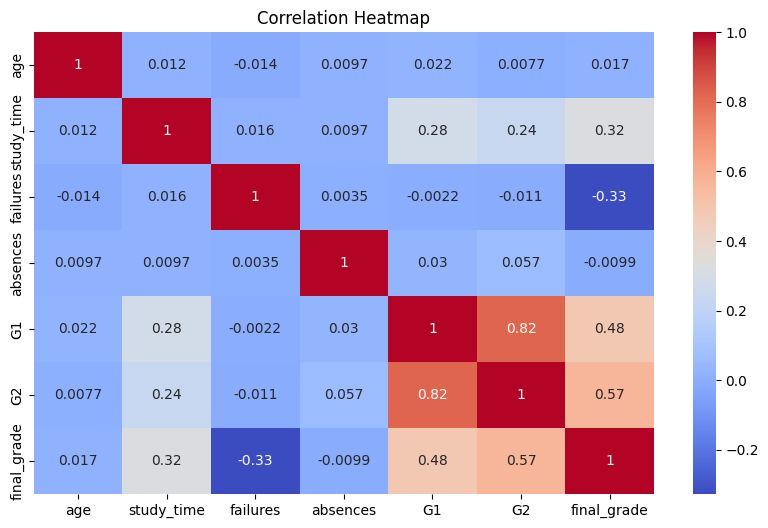

In [ ]:
# ================================
# 4. Exploratory Data Analysis
# ================================

sns.histplot(df['final_grade'], kde=True)
plt.title("Distribution of Final Grades")
plt.show()

sns.boxplot(x="study_time", y="final_grade", data=df)
plt.title("Final Grade by Study Time")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df[num_features + ["final_grade"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# ================================
# 5. Regression Model: Predict Final Grade
# ================================

X = df[num_features + cat_features]
y = df["final_grade"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = Pipeline([
    ("pre", preprocessor),
    ("model", LinearRegression())
])

reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Save model
joblib.dump(reg_model, "linear_regression.pkl")


Linear Regression R2: 0.42849237875195556
MSE: 4.030780958331741


['linear_regression.pkl']

Decision Tree Accuracy: 0.7533333333333333
[[ 21  58]
 [ 16 205]]
              precision    recall  f1-score   support

           0       0.57      0.27      0.36        79
           1       0.78      0.93      0.85       221

    accuracy                           0.75       300
   macro avg       0.67      0.60      0.60       300
weighted avg       0.72      0.75      0.72       300

Random Forest Accuracy: 0.7533333333333333
[[ 26  53]
 [ 21 200]]
              precision    recall  f1-score   support

           0       0.55      0.33      0.41        79
           1       0.79      0.90      0.84       221

    accuracy                           0.75       300
   macro avg       0.67      0.62      0.63       300
weighted avg       0.73      0.75      0.73       300



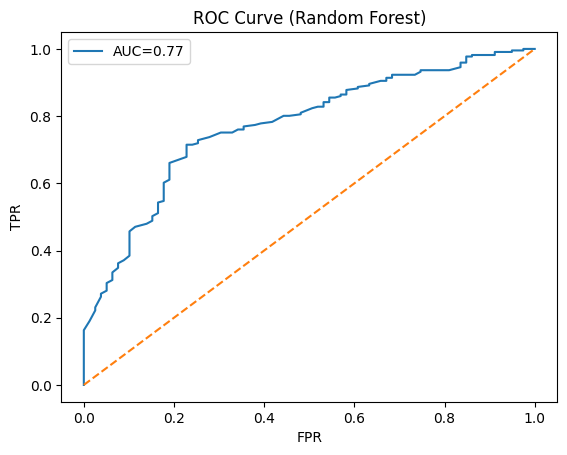

['random_forest.pkl']

In [ ]:
# ================================
# 6. Classification Models: Predict Pass/Fail
# ================================

y_class = df["pass_fail"]

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Decision Tree
dt_model = Pipeline([
    ("pre", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# Random Forest
rf_model = Pipeline([
    ("pre", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# ROC curve
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_rf):.2f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve (Random Forest)")
plt.legend(); plt.show()

# Save models
joblib.dump(dt_model, "decision_tree.pkl")
joblib.dump(rf_model, "random_forest.pkl")


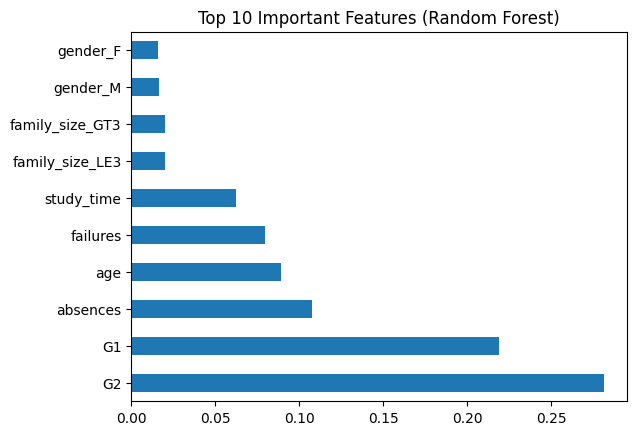

In [ ]:
# ================================
# 7. Feature Importance (Random Forest)
# ================================

rf = rf_model.named_steps["model"]
pre = rf_model.named_steps["pre"]

# Get feature names
ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(cat_features)
all_features = num_features + list(cat_names)

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Important Features (Random Forest)")
plt.show()
